# Threshold Tuning (v7 Models)

No retraining needed for this one. The v7 models are already trained, we just want to see if changing the decision thresholds gets us better results.

Model A threshold controls how aggressively we flag cancellations. Model B threshold controls how aggressively we flag delays. We used 0.5 for both throughout v5-v8 and never actually questioned it. This notebook tests a bunch of combinations to find something better.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load the v7 Models

Loading model_a and model_b from v7 since those were our best results.

In [3]:
# load v7 models -- change path if needed
model_a = joblib.load(r'C:\Users\fabix\Desktop\thesis\modelos\model_a_v7.pkl')
model_b = joblib.load(r'C:\Users\fabix\Desktop\thesis\modelos\model_b_v7.pkl')
print('models loaded')

models loaded


## Load Data

Same dataset as v7, just need the val and test splits.

In [4]:
df = pd.read_parquet('../../../1_download_data/cleansed/modeling_dataset.parquet')

val  = df[df['split'] == 'val']
test = df[df['split'] == 'test']

features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay'
]
features = [f for f in features if f in df.columns]

X_val  = val[features].fillna(val[features].median())
X_test = test[features].fillna(val[features].median())

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

prob_cancel_val = model_a.predict_proba(X_val)[:, 1]
prob_delay_val  = model_b.predict_proba(X_val)[:, 1]
print('probabilities computed')

probabilities computed


## Testing All Threshold Combinations

Testing every combination of thresh_a (0.2 to 0.5) and thresh_b (0.3 to 0.6) on the val set. Once we find the best combo we run it on test exactly once.

In [5]:
thresholds_a = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
thresholds_b = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

results = []

for ta in thresholds_a:
    for tb in thresholds_b:
        cancelled = prob_cancel_val >= ta
        delayed   = prob_delay_val  >= tb
        y_pred = np.where(cancelled, 2, np.where(delayed, 1, 0))
        
        mf1 = f1_score(y_val_true, y_pred, average='macro')
        
        # per class metrics
        from sklearn.metrics import precision_recall_fscore_support
        p, r, f, _ = precision_recall_fscore_support(y_val_true, y_pred,
                                                      labels=[0,1,2],
                                                      zero_division=0)
        results.append({
            'thresh_a': ta, 'thresh_b': tb,
            'val_macro_f1': round(mf1, 4),
            'ontime_recall':    round(r[0], 3),
            'delayed_recall':   round(r[1], 3),
            'cancelled_recall': round(r[2], 3),
            'cancelled_precision': round(p[2], 3),
        })

results_df = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False)
print('top 10 combos:')
print(results_df.head(10).to_string(index=False))

top 10 combos:
 thresh_a  thresh_b  val_macro_f1  ontime_recall  delayed_recall  cancelled_recall  cancelled_precision
     0.50      0.60        0.4325          0.867           0.315             0.100                0.126
     0.45      0.60        0.4320          0.864           0.310             0.122                0.106
     0.50      0.55        0.4312          0.795           0.425             0.100                0.126
     0.45      0.55        0.4310          0.793           0.418             0.122                0.106
     0.40      0.60        0.4295          0.860           0.302             0.149                0.090
     0.40      0.55        0.4290          0.789           0.409             0.149                0.090
     0.35      0.55        0.4248          0.784           0.397             0.181                0.075
     0.35      0.60        0.4247          0.853           0.291             0.181                0.075
     0.30      0.55        0.4184          0.774 

## Cancelled Recall vs Macro F1

Lower thresholds catch more cancellations but hurt overall F1. This plot shows where the sweet spot is.

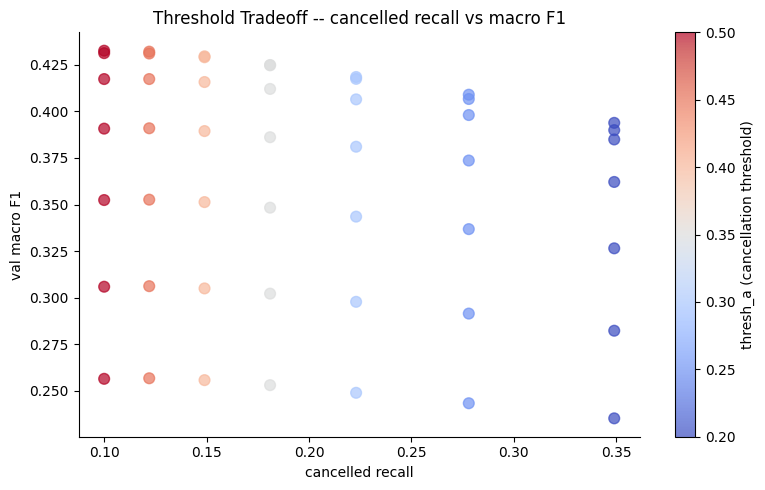

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(results_df['cancelled_recall'], results_df['val_macro_f1'],
                c=results_df['thresh_a'], cmap='coolwarm', alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label='thresh_a (cancellation threshold)')
ax.set_xlabel('cancelled recall')
ax.set_ylabel('val macro F1')
ax.set_title('Threshold Tradeoff -- cancelled recall vs macro F1')
plt.tight_layout()
plt.show()

## Test Set Results

Best combo from val, run on test once.

best combo: thresh_a=0.5, thresh_b=0.6
val macro F1: 0.4325

test macro F1: 0.4445
              precision    recall  f1-score   support

     on_time       0.81      0.85      0.83   3091391
     delayed       0.38      0.33      0.36    863057
   cancelled       0.19      0.13      0.15    123191

    accuracy                           0.72   4077639
   macro avg       0.46      0.44      0.44   4077639
weighted avg       0.70      0.72      0.71   4077639



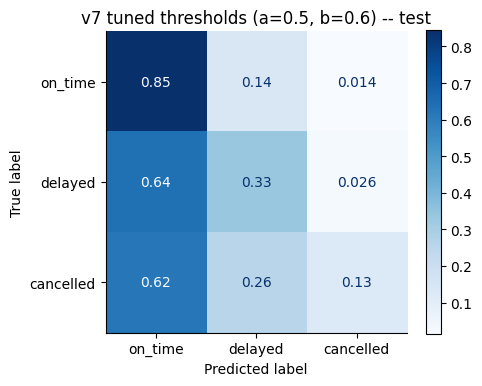

In [7]:
best = results_df.iloc[0]
ta_best = best['thresh_a']
tb_best = best['thresh_b']
print(f'best combo: thresh_a={ta_best}, thresh_b={tb_best}')
print(f'val macro F1: {best["val_macro_f1"]}')

# now run on test -- only once
cancelled_test = model_a.predict_proba(X_test)[:, 1] >= ta_best
delayed_test   = model_b.predict_proba(X_test)[:, 1] >= tb_best
y_test_pred = np.where(cancelled_test, 2, np.where(delayed_test, 1, 0))

mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'\ntest macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'v7 tuned thresholds (a={ta_best}, b={tb_best}) -- test')
plt.tight_layout()
plt.show()

## Default vs Tuned

How much did threshold tuning actually help over the v7 default of 0.5/0.5?

In [8]:
# default thresholds for comparison
cancelled_def = model_a.predict_proba(X_test)[:, 1] >= 0.5
delayed_def   = model_b.predict_proba(X_test)[:, 1] >= 0.5
y_default = np.where(cancelled_def, 2, np.where(delayed_def, 1, 0))
mf1_default = f1_score(y_test_true, y_default, average='macro')

comparison = pd.DataFrame({
    'model':         ['v7 default (0.5/0.5)', f'v7 tuned ({ta_best}/{tb_best})'],
    'test macro F1': [round(mf1_default, 4), round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

               model  test macro F1
v7 default (0.5/0.5)         0.4329
  v7 tuned (0.5/0.6)         0.4445
